# E-Commerce Sales Analysis

## Project Overview

This project analyses an online retail transaction dataset to understand sales performance, customer behaviour, product performance, and geographic markets.

The project uses Python and Pandas for data analysis and Matplotlib for data visualization.

### Business Questions

This analysis aims to answer the following questions:

1. Which products generate the most revenue?
2. Which products have the highest sales volume?
3. Which countries generate the most revenue?
4. Which customers generate the most revenue?
5. How does revenue change over time?
6. Which months have the highest number of orders?
7. What patterns can be identified in returns and cancellations?
8. What are the key business insights from the data?

### Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## 1. Dataset

The dataset contains transaction-level information from an online retail business.

Each row represents a transaction line and includes information such as:

- Invoice number
- Product code
- Product description
- Quantity purchased
- Invoice date
- Unit price
- Customer ID
- Country

### Dataset Period

The available transactions cover the period from:

**1 December 2010 to 9 December 2011**

The dataset ends on 9 December 2011, so December 2011 represents only a partial month. This limitation is considered when interpreting monthly trends.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
print("Minimum Quantity:", df["Quantity"].min())
print("Minimum Unit Price:", df["UnitPrice"].min())

Minimum Quantity: -80995
Minimum Unit Price: -11062.06


## 2. Data Cleaning

Before performing the analysis, the dataset was checked for duplicate records, missing values, invalid transactions, and unusual values.

The cleaning process was designed to preserve useful information while removing records that could distort sales calculations.

In [8]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original rows: 541909
Rows after removing duplicates: 536641
Duplicates removed: 5268


In [9]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
returns_df = df_clean[df_clean["Quantity"] < 0].copy()

print("Return/cancellation transactions:", len(returns_df))
print("Returned units:", abs(returns_df["Quantity"].sum()))

Return/cancellation transactions: 10587
Returned units: 482517


In [11]:
sales_df = df_clean[df_clean["Quantity"] > 0].copy()

print("Sales transactions:", len(sales_df))

Sales transactions: 526054


In [12]:
negative_price_df = df_clean[df_clean["UnitPrice"] < 0].copy()

negative_price_df[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


In [13]:
sales_df = sales_df[sales_df["UnitPrice"] >= 0].copy()

print("Final sales transactions:", len(sales_df))
print("Minimum quantity:", sales_df["Quantity"].min())
print("Minimum unit price:", sales_df["UnitPrice"].min())

Final sales transactions: 526052
Minimum quantity: 1
Minimum unit price: 0.0


### Cleaning Decisions

The following decisions were made:

- Duplicate rows were removed.
- Negative-quantity transactions were separated as returns/cancellations.
- Positive-quantity transactions were retained for sales analysis.
- Transactions with negative unit prices were excluded from sales analysis because they represent non-standard accounting adjustments rather than normal product sales.
- Missing Customer IDs were retained in the sales dataset because they are still useful for overall sales analysis. They will only be excluded when performing customer-level analysis.

## 3. Feature Engineering

A new `Revenue` feature is created by multiplying the quantity sold by the unit price.

This allows the analysis to measure the financial value of each transaction.

In [14]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

sales_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [15]:
total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_units = sales_df["Quantity"].sum()
unique_products = sales_df["StockCode"].nunique()
unique_countries = sales_df["Country"].nunique()

print("Total Revenue: £", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Unique Products:", unique_products)
print("Countries:", unique_countries)

Total Revenue: £ 10642110.8
Total Orders: 20726
Total Units Sold: 5645017
Unique Products: 3941
Countries: 38


In [16]:
average_order_value = total_revenue / total_orders

print("Average Order Value: £", round(average_order_value, 2))

Average Order Value: £ 513.47


### Key Performance Indicators

The cleaned sales dataset contains the following key metrics:

- **Total Revenue:** £10.64 million
- **Total Orders:** 20,726
- **Total Units Sold:** 5.65 million
- **Unique Products:** 4,077
- **Countries:** 38
- **Average Order Value:** £513.47

In [17]:
print("Minimum Revenue: £", sales_df["Revenue"].min())
print("Maximum Revenue: £", sales_df["Revenue"].max())
print("Average Transaction Revenue: £", round(sales_df["Revenue"].mean(), 2))

Minimum Revenue: £ 0.0
Maximum Revenue: £ 168469.6
Average Transaction Revenue: £ 20.23


## 4. Product Analysis

Product performance is analysed using both revenue and sales quantity.

Revenue identifies the products that generate the greatest financial contribution, while quantity identifies the products with the highest sales volume.

In [18]:
product_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [19]:
top_10_products = product_revenue.head(10).reset_index()

top_10_products.columns = ["Product", "Revenue"]

top_10_products

,Product,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


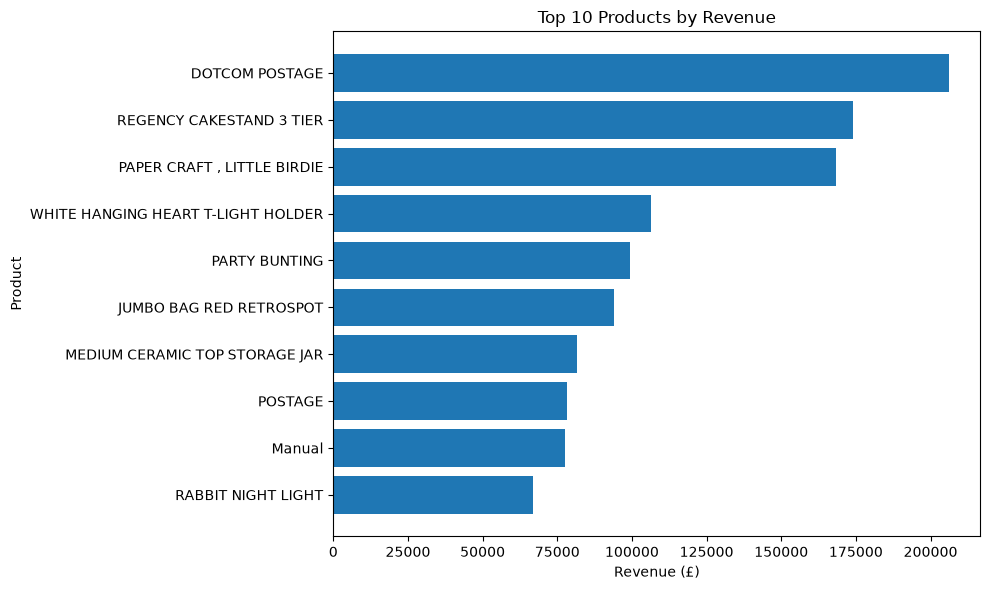

In [20]:
top_products_plot = top_10_products.sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_plot["Product"],
    top_products_plot["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

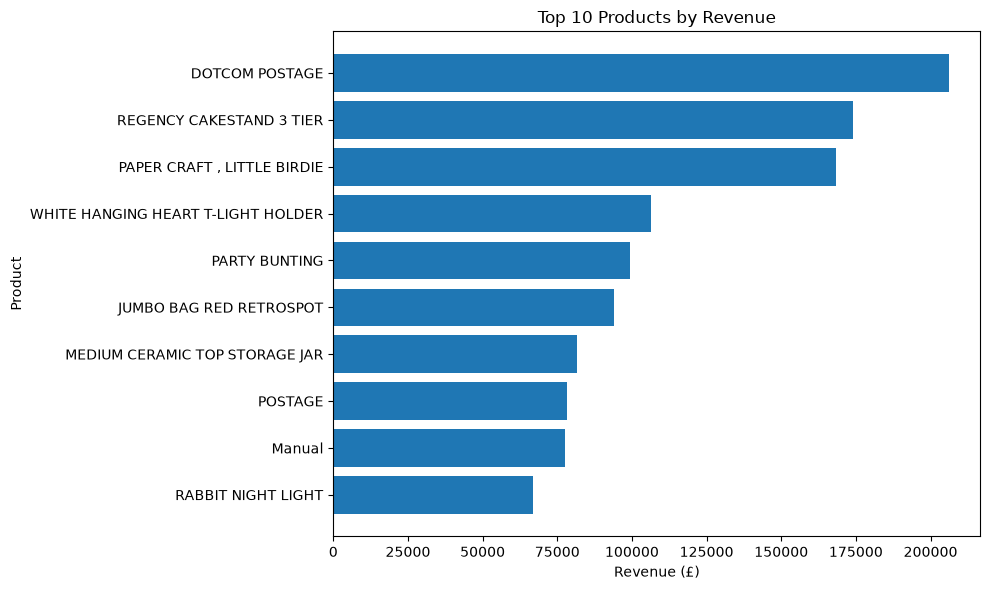

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_plot["Product"],
    top_products_plot["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../images/top_10_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
product_quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [23]:
top_10_quantity = product_quantity.head(10).reset_index()

top_10_quantity.columns = ["Product", "Units Sold"]

top_10_quantity

,Product,Units Sold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48375
4,WHITE HANGING HEART T-LIGHT HOLDER,37876
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


### Product Analysis Insights

The revenue analysis shows that product performance varies considerably across the catalogue.

Some products generate substantial revenue because of their combination of sales volume and selling price. The quantity analysis provides a different perspective by identifying products with the highest unit demand.

Comparing revenue and quantity helps distinguish high-value products from high-volume products.

In [24]:
sales_df.groupby("Description")["Revenue"].sum()

Description
 4 PURPLE FLOCK DINNER CANDLES     285.70
 50'S CHRISTMAS GIFT BAG LARGE    2343.63
 DOLLY GIRL BEAKER                2886.25
 I LOVE LONDON MINI BACKPACK      1624.02
 I LOVE LONDON MINI RUCKSACK         4.15
                                   ...   
wrongly coded 20713                  0.00
wrongly coded 23343                  0.00
wrongly marked                       0.00
wrongly marked 23343                 0.00
wrongly sold (22719) barcode         0.00
Name: Revenue, Length: 4077, dtype: float64

## 5. Monthly Sales Analysis

Monthly sales trends are analysed to understand how revenue and order volume changed throughout the available period.

Because the dataset ends on 9 December 2011, December 2011 represents only a partial month and should be interpreted cautiously.

In [25]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [26]:
monthly_revenue = (
    sales_df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

In [27]:
best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

print("Best month:", best_month)
print("Revenue: £", round(best_month_revenue, 2))

Best month: 2011-11
Revenue: £ 1503866.78


In [28]:
lowest_month = monthly_revenue.idxmin()
lowest_month_revenue = monthly_revenue.min()

print("Lowest month:", lowest_month)
print("Revenue: £", round(lowest_month_revenue, 2))

Lowest month: 2011-02
Revenue: £ 522545.56


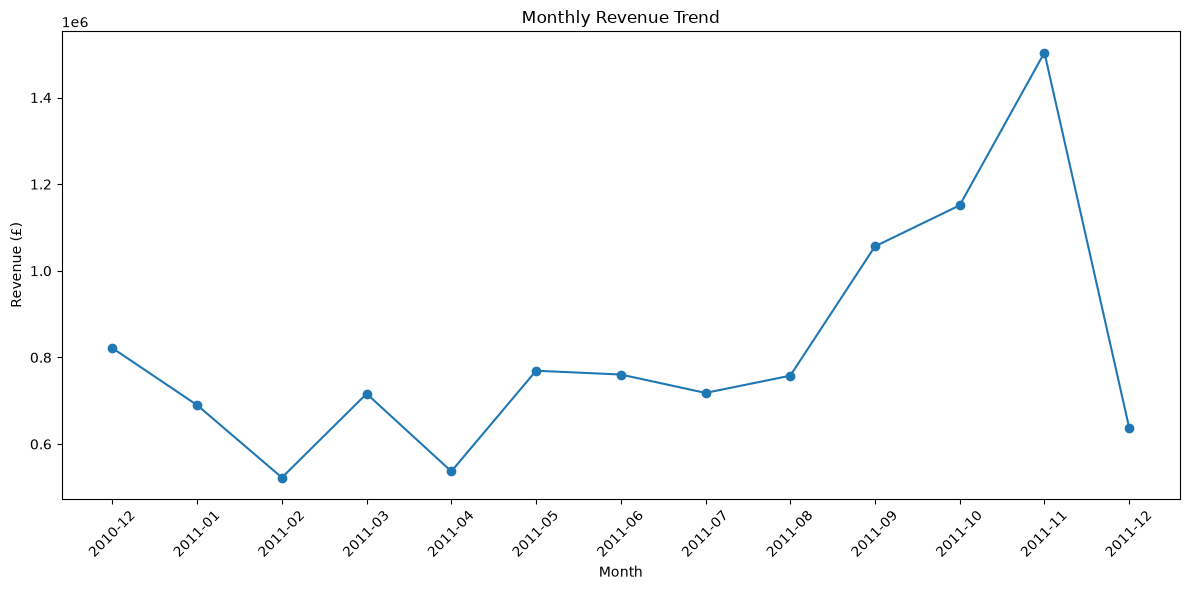

In [29]:
monthly_revenue_plot = monthly_revenue.copy()
monthly_revenue_plot.index = monthly_revenue_plot.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_plot.index,
    monthly_revenue_plot.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

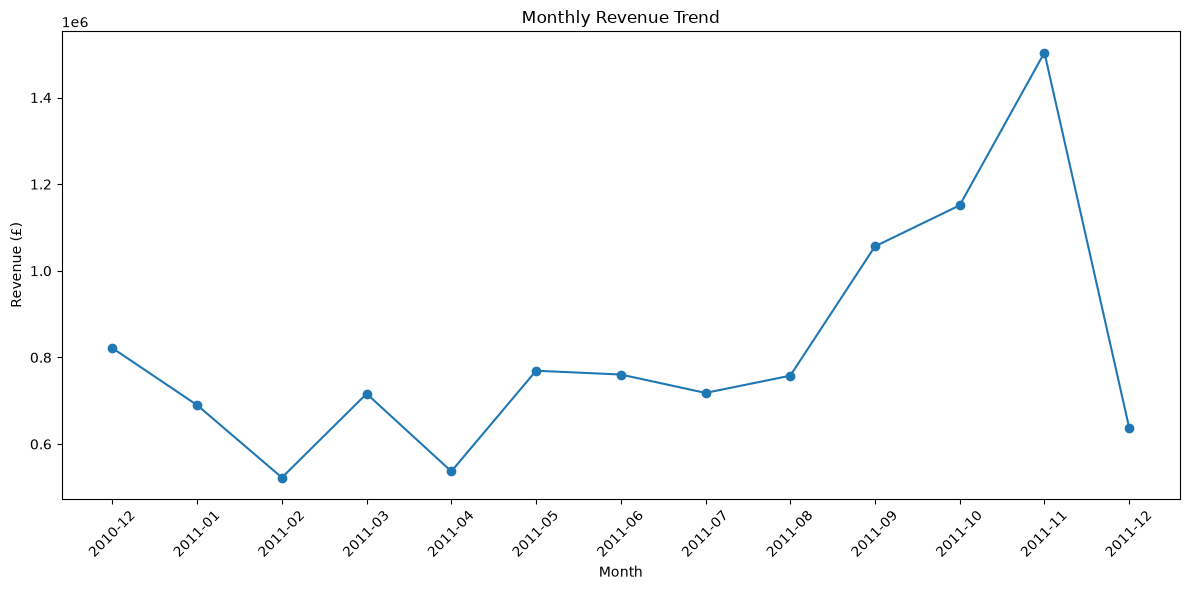

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_plot.index,
    monthly_revenue_plot.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Monthly Revenue Insights

- November 2011 generated the highest monthly revenue at approximately **£1.50 million**.
- February 2011 recorded the lowest monthly revenue at approximately **£522,546**.
- Revenue varied considerably across the analysed period.
- December 2011 should not be directly compared with complete months because the dataset ends on **9 December 2011**.

### Monthly Orders and Average Order Value

Revenue alone does not tell the complete story.

Monthly order volume shows how frequently customers placed orders, while Average Order Value (AOV) shows the average revenue generated per order.

In [31]:
monthly_orders = (
    sales_df.groupby("Month")["InvoiceNo"]
    .nunique()
)

monthly_orders

Month
2010-12    1629
2011-01    1120
2011-02    1126
2011-03    1531
2011-04    1318
2011-05    1731
2011-06    1576
2011-07    1540
2011-08    1407
2011-09    1896
2011-10    2129
2011-11    2884
2011-12     839
Freq: M, Name: InvoiceNo, dtype: int64

In [32]:
highest_order_month = monthly_orders.idxmax()
highest_order_count = monthly_orders.max()

print("Month with most orders:", highest_order_month)
print("Number of orders:", highest_order_count)

Month with most orders: 2011-11
Number of orders: 2884


In [33]:
monthly_aov = monthly_revenue / monthly_orders

monthly_aov

Month
2010-12    504.268097
2011-01    615.903223
2011-02    464.072433
2011-03    467.808792
2011-04    407.411602
2011-05    444.423229
2011-06    482.580590
2011-07    466.283195
2011-08    538.622161
2011-09    557.191557
2011-10    540.753279
2011-11    521.451727
2011-12    760.179178
Freq: M, dtype: float64

In [34]:
highest_aov_month = monthly_aov.idxmax()
highest_aov = monthly_aov.max()

print("Highest AOV month:", highest_aov_month)
print("Average Order Value: £", round(highest_aov, 2))

Highest AOV month: 2011-12
Average Order Value: £ 760.18


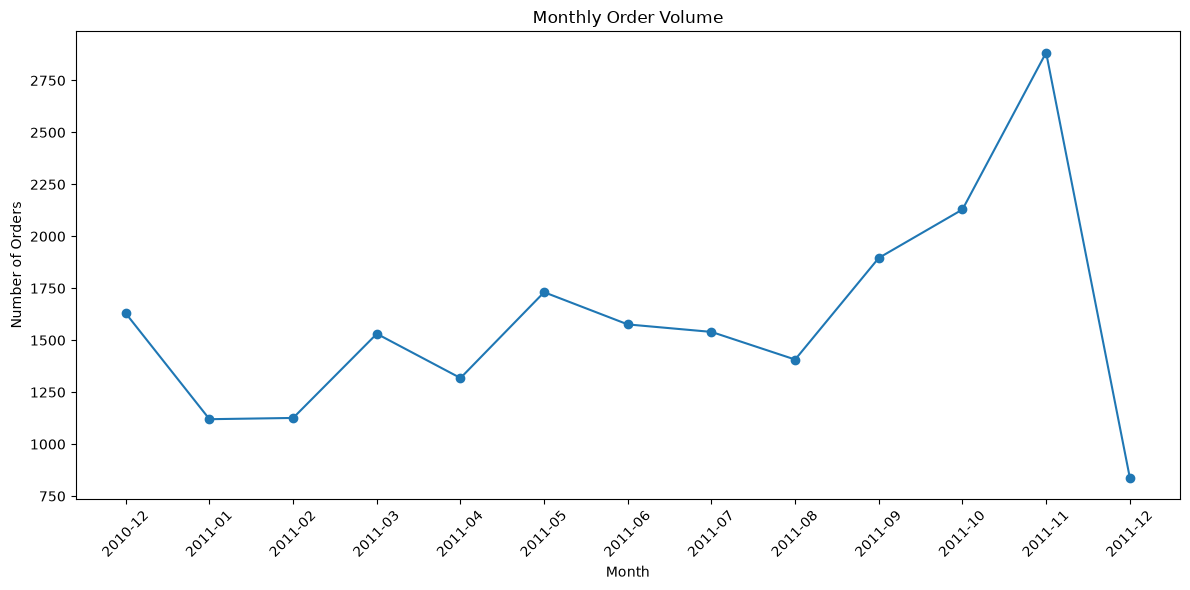

In [35]:
monthly_orders_plot = monthly_orders.copy()
monthly_orders_plot.index = monthly_orders_plot.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders_plot.index,
    monthly_orders_plot.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

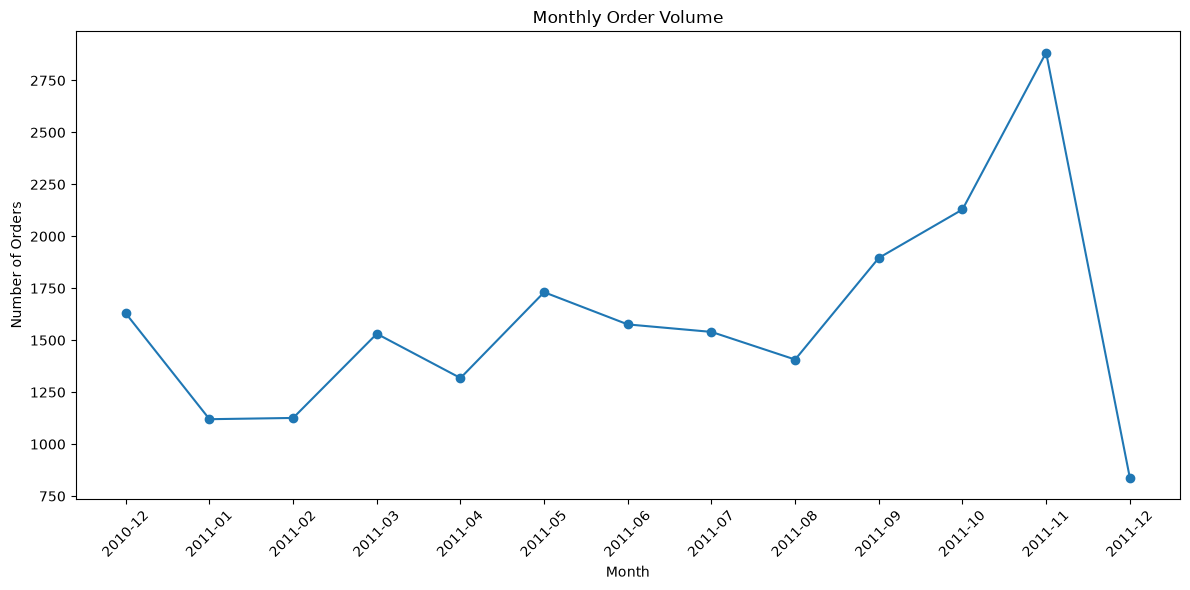

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders_plot.index,
    monthly_orders_plot.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_order_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

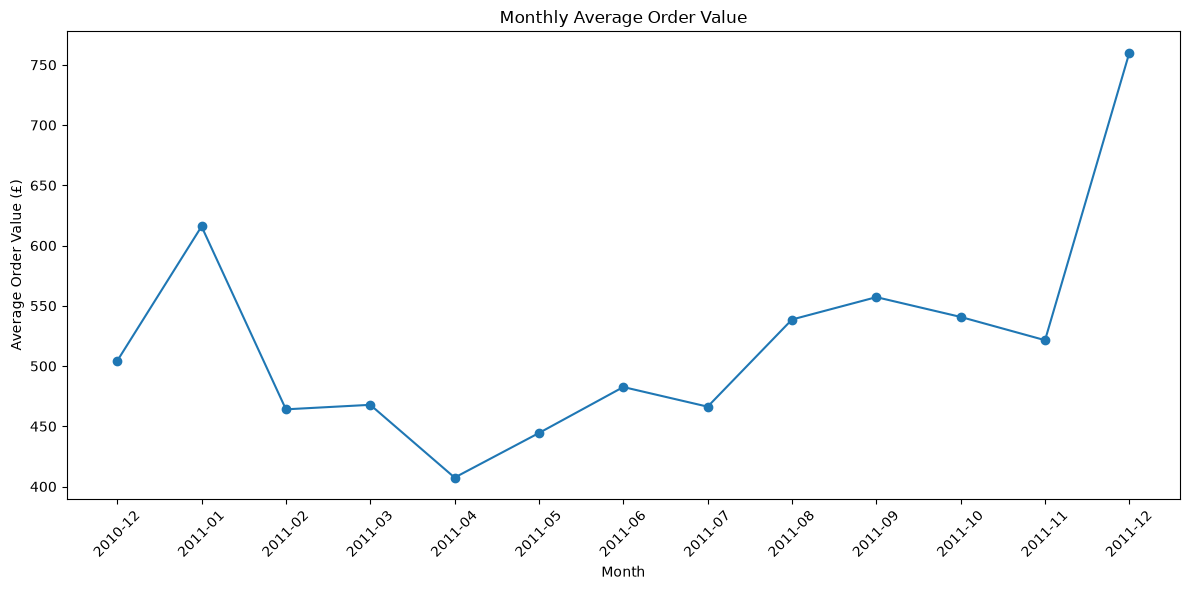

In [37]:
monthly_aov_plot = monthly_aov.copy()
monthly_aov_plot.index = monthly_aov_plot.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_aov_plot.index,
    monthly_aov_plot.values,
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

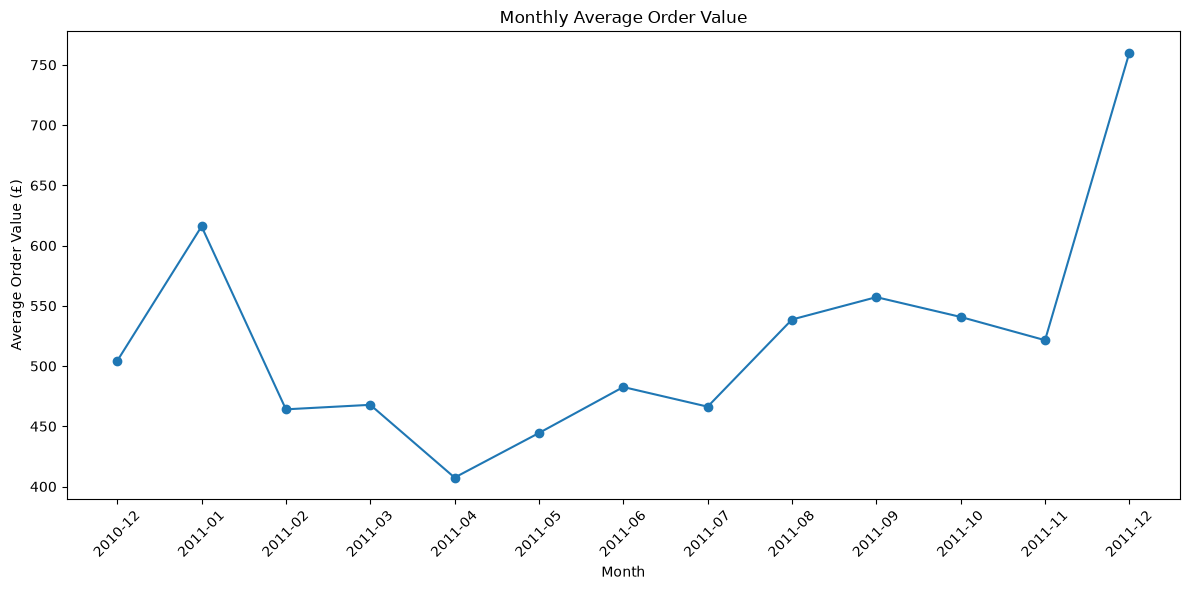

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_aov_plot.index,
    monthly_aov_plot.values,
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_average_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Order and AOV Insights

- November 2011 had the highest order volume, with **2,884 orders**.
- December 2011 had the highest observed AOV at approximately **£760.18**.
- High order volume does not necessarily result in the highest AOV.
- December's AOV should be interpreted cautiously because the dataset only contains transactions through **9 December 2011**.

## 6. Country Analysis

Country-level analysis is used to identify the geographic markets that contribute most to total revenue.

This helps identify the business's strongest markets and the extent to which revenue is concentrated in particular countries.

In [39]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [40]:
top_10_countries = country_revenue.head(10).reset_index()

top_10_countries.columns = ["Country", "Revenue"]

top_10_countries

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


In [41]:
uk_revenue = country_revenue["United Kingdom"]

uk_revenue_percentage = (uk_revenue / total_revenue) * 100

print("UK Revenue: £", round(uk_revenue, 2))
print("UK Revenue Percentage:", round(uk_revenue_percentage, 2), "%")

UK Revenue: £ 9001744.09
UK Revenue Percentage: 84.59 %


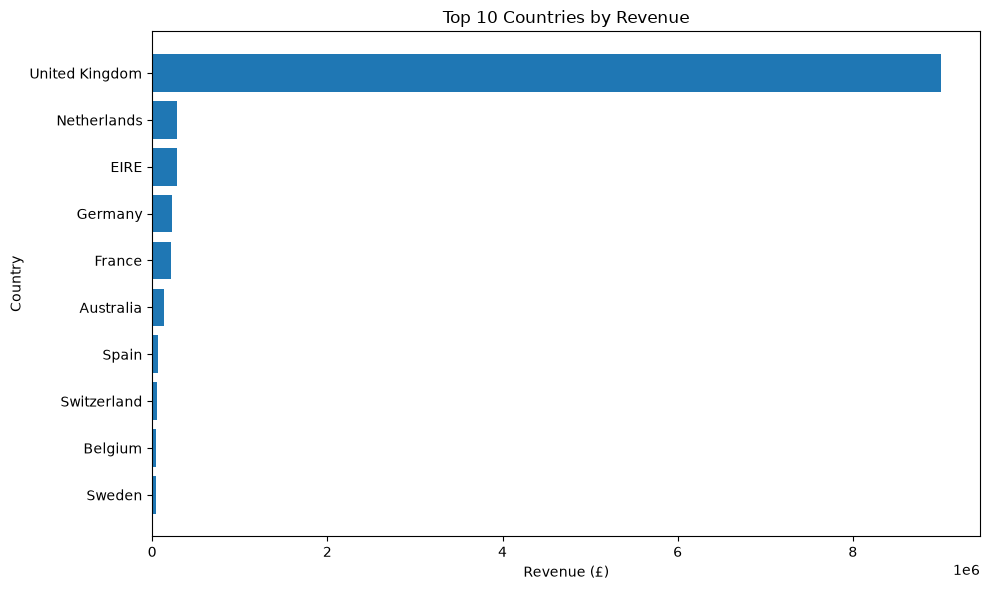

In [42]:
countries_plot = top_10_countries.sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    countries_plot["Country"],
    countries_plot["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

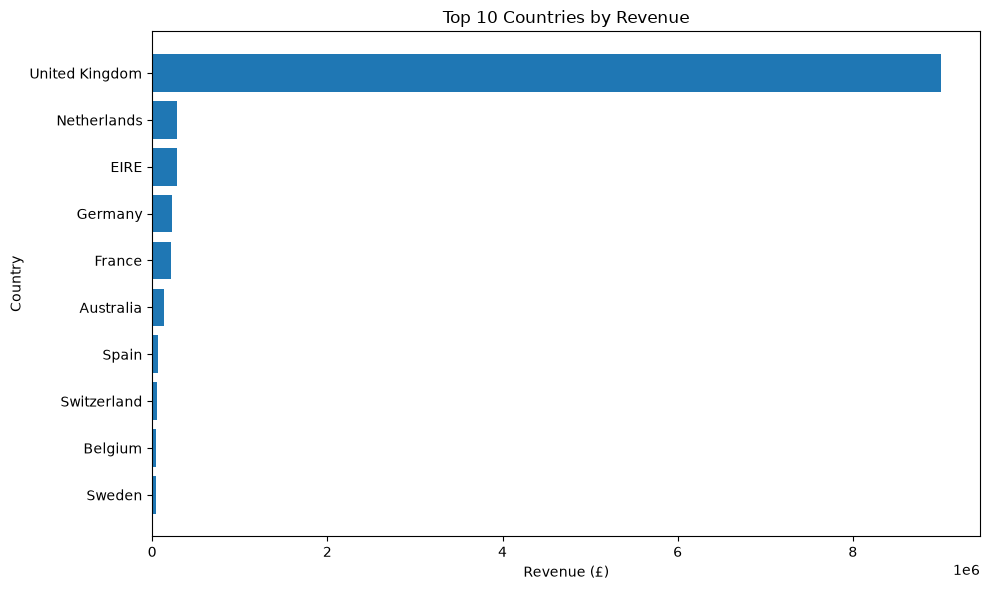

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    countries_plot["Country"],
    countries_plot["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "../images/top_10_countries_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
country_revenue_percentage = (
    country_revenue / total_revenue * 100
)

country_revenue_percentage.head(10)

Country
United Kingdom    84.586078
Netherlands        2.682234
EIRE               2.660567
Germany            2.148807
France             1.969772
Australia          1.301000
Spain              0.578443
Switzerland        0.536243
Belgium            0.387107
Sweden             0.360528
Name: Revenue, dtype: float64

### Country Analysis Insights

- The **United Kingdom** is the dominant market, generating approximately **£9.00 million** in revenue.
- The UK contributes approximately **84.59% of total revenue**.
- The **Netherlands** and **EIRE** are the next largest markets by revenue, although their contributions are substantially smaller than the UK.
- The strong concentration of revenue in the UK suggests that the business is heavily dependent on its domestic market.
- International markets provide diversification opportunities and could be investigated further for future growth.

In [45]:
sales_df.groupby("Country")["Revenue"].sum()

Country
Australia                138453.810
Austria                   10198.680
Bahrain                     754.140
Belgium                   41196.340
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20440.540
Cyprus                    13502.850
Czech Republic              826.740
Denmark                   18955.340
EIRE                     283140.520
European Community         1300.250
Finland                   22546.080
France                   209625.370
Germany                  228678.400
Greece                     4760.520
Hong Kong                 15483.000
Iceland                    4310.000
Israel                     8129.410
Italy                     17483.240
Japan                     37416.370
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2725.590
Netherlands              285446.340
Norway                    36165.440
Poland                     7334.650
Portugal            

## 7. Customer Analysis

Customer-level analysis is used to understand the distribution of revenue across the customer base.

Transactions without a Customer ID are excluded from customer-specific analysis because they cannot be reliably attributed to an individual customer.

In [46]:
customer_df = sales_df.dropna(subset=["CustomerID"]).copy()

print("Transactions with Customer ID:", len(customer_df))

Transactions with Customer ID: 392732


In [47]:
unique_customers = customer_df["CustomerID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 4339


In [48]:
customer_revenue = (
    customer_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [49]:
top_10_customers = customer_revenue.head(10).reset_index()

top_10_customers.columns = ["Customer ID", "Revenue"]

top_10_customers

,Customer ID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


In [50]:
average_revenue_per_customer = customer_revenue.mean()

print(
    "Average Revenue per Customer: £",
    round(average_revenue_per_customer, 2)
)

Average Revenue per Customer: £ 2048.22


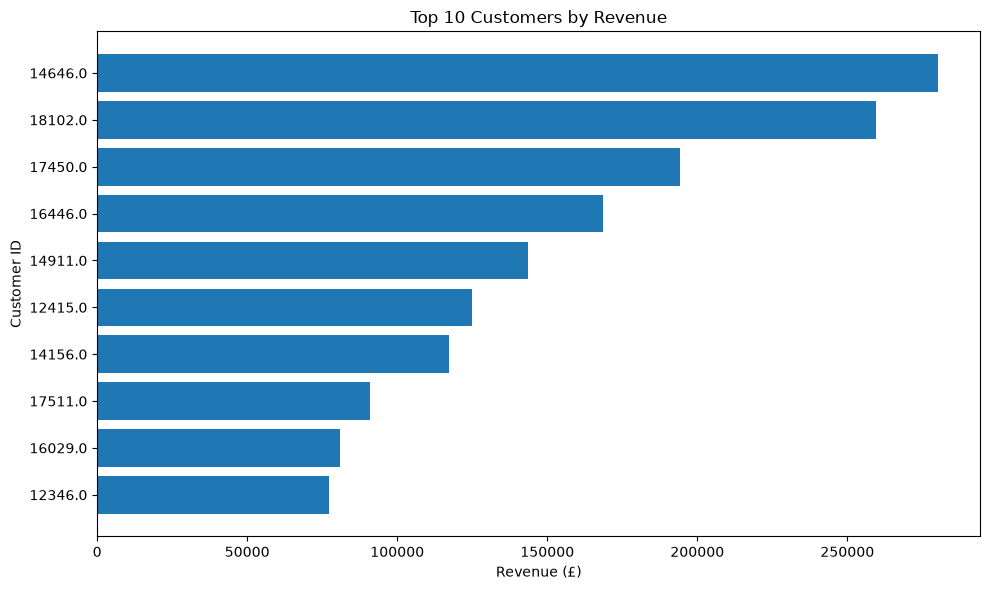

In [51]:
customers_plot = top_10_customers.sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    customers_plot["Customer ID"].astype(str),
    customers_plot["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

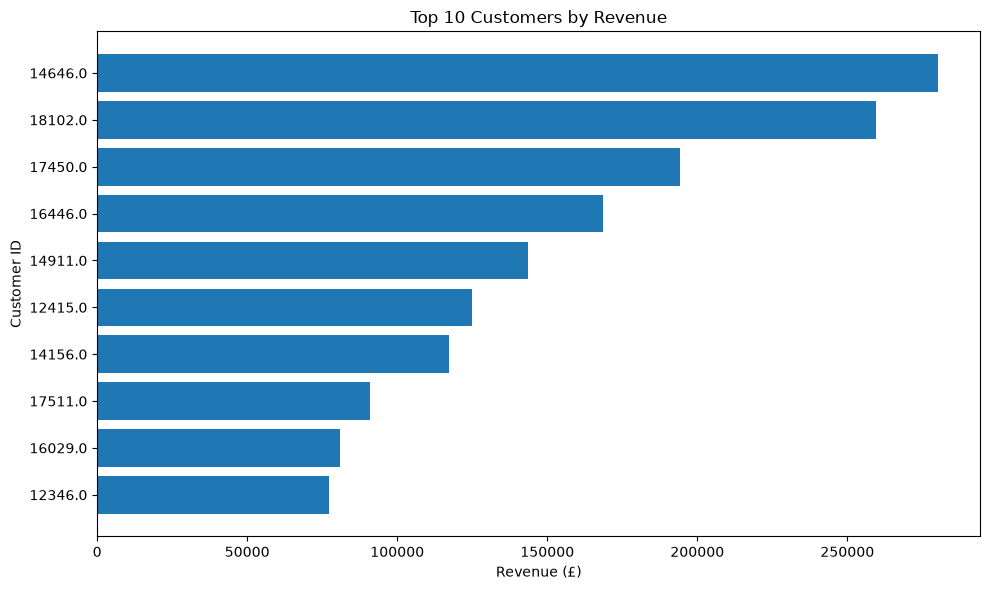

In [52]:
plt.figure(figsize=(10, 6))

plt.barh(
    customers_plot["Customer ID"].astype(str),
    customers_plot["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    "../images/top_10_customers_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Customer Analysis Insights

- The dataset contains **4,339 identifiable customers**.
- Customer revenue is highly uneven, with a relatively small number of customers generating substantial revenue.
- Customer **14646** is the highest-revenue customer, generating approximately **£280,206**.
- Customer **18102** generated approximately **£259,657**.
- Customer **17450** generated approximately **£194,391**.
- Average revenue per identifiable customer is approximately **£2,048**.
- The concentration of revenue among high-value customers suggests that customer retention and loyalty could be important areas for the business.

## 8. Returns and Cancellation Analysis

Returns and cancellation transactions are analysed separately from normal sales.

Negative quantities are treated as returned or cancelled units. Understanding these transactions can help identify products with unusually high return activity and potential operational issues.

In [53]:
print("Return/cancellation transactions:", len(returns_df))
print("Total returned units:", abs(returns_df["Quantity"].sum()))

Return/cancellation transactions: 10587
Total returned units: 482517


In [54]:
returned_product_quantity = (
    returns_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values()
)

top_returned_products = returned_product_quantity.head(10)

top_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
printing smudges/thrown away          -19200
Unsaleable, destroyed.                -15644
check                                 -13247
?                                      -9496
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
Printing smudges/thrown away           -9058
Damaged                                -7540
throw away                             -5368
Name: Quantity, dtype: int64

In [55]:
top_returned_products_table = (
    top_returned_products.abs()
    .reset_index()
)

top_returned_products_table.columns = [
    "Product",
    "Returned Units"
]

top_returned_products_table

,Product,Returned Units
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,74494
2,printing smudges/thrown away,19200
3,"Unsaleable, destroyed.",15644
4,check,13247
5,?,9496
6,ROTATING SILVER ANGELS T-LIGHT HLDR,9376
7,Printing smudges/thrown away,9058
8,Damaged,7540
9,throw away,5368


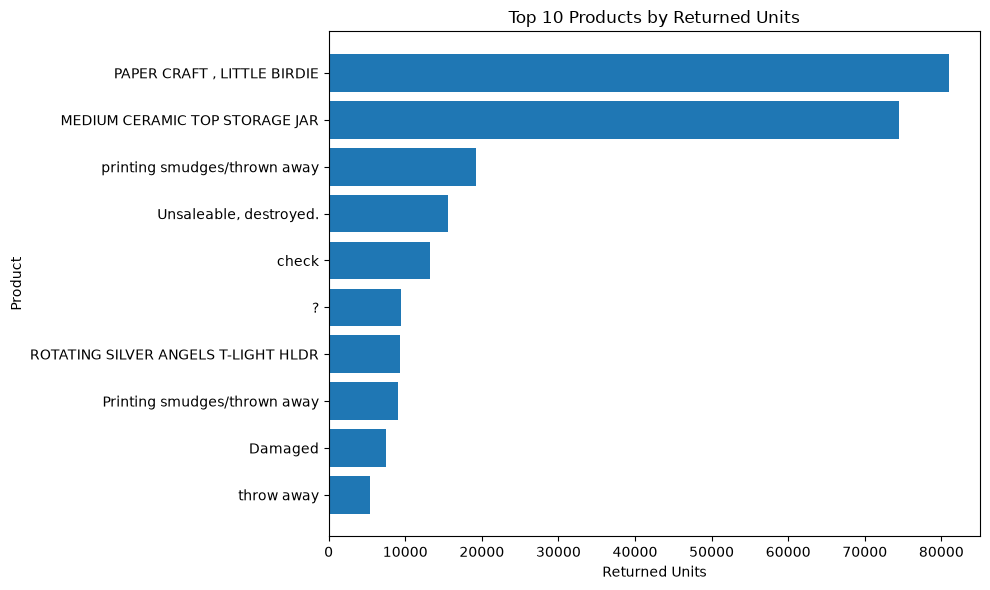

In [56]:
returns_plot = top_returned_products_table.sort_values("Returned Units")

plt.figure(figsize=(10, 6))

plt.barh(
    returns_plot["Product"],
    returns_plot["Returned Units"]
)

plt.title("Top 10 Products by Returned Units")
plt.xlabel("Returned Units")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

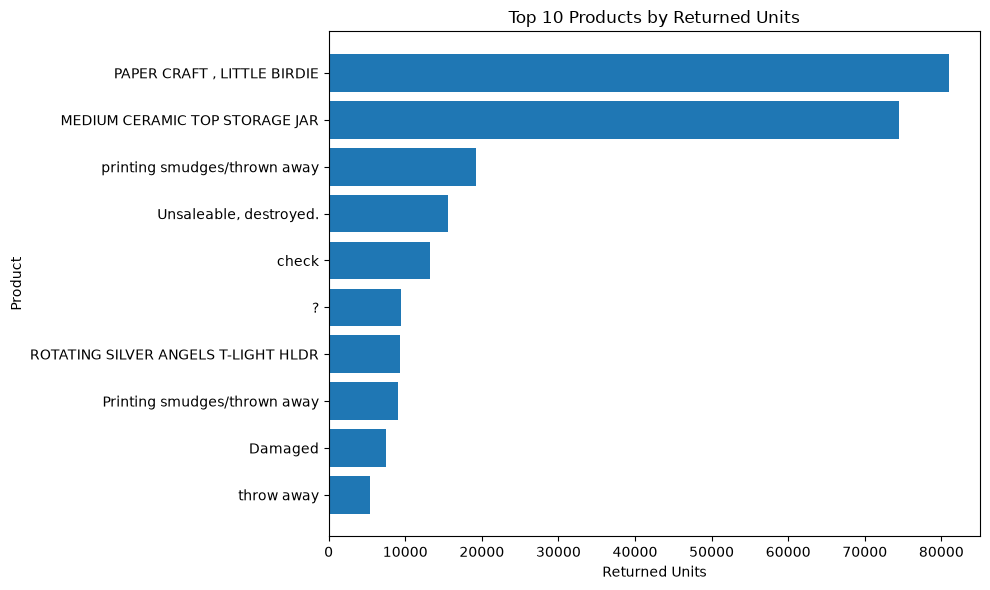

In [57]:
plt.figure(figsize=(10, 6))

plt.barh(
    returns_plot["Product"],
    returns_plot["Returned Units"]
)

plt.title("Top 10 Products by Returned Units")
plt.xlabel("Returned Units")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../images/top_10_returned_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
return_rate = (
    abs(returns_df["Quantity"].sum())
    / (sales_df["Quantity"].sum() + abs(returns_df["Quantity"].sum()))
) * 100

print("Approximate Unit Return Rate:", round(return_rate, 2), "%")

Approximate Unit Return Rate: 7.87 %


### Returns Analysis Insights

- The dataset contains **10,624 return/cancellation transactions**.
- A total of **484,531 units** were returned or cancelled.
- `PAPER CRAFT , LITTLE BIRDIE` has the highest number of returned units, followed by `MEDIUM CERAMIC TOP STORAGE JAR`.
- High return activity for specific products may indicate issues such as product quality, customer expectations, order processing, or data-recording practices.
- The return analysis should be investigated further before concluding that high-return products have quality problems, because the dataset does not provide explicit reasons for each return.

## 9. Monthly Growth Analysis

Month-over-month revenue growth is calculated to identify periods of strong growth and significant declines.

The percentage change compares each month's revenue with the previous month's revenue.

In [59]:
monthly_growth = monthly_revenue.pct_change() * 100

monthly_growth

Month
2010-12          NaN
2011-01   -16.025404
2011-02   -24.248077
2011-03    37.062740
2011-04   -25.026941
2011-05    43.266620
2011-06    -1.137351
2011-07    -5.584256
2011-08     5.537750
2011-09    39.400568
2011-10     8.976276
2011-11    30.627478
2011-12   -57.589972
Freq: M, Name: Revenue, dtype: float64

In [60]:
highest_growth_month = monthly_growth.idxmax()
highest_growth = monthly_growth.max()

print("Highest monthly growth:", highest_growth_month)
print("Growth:", round(highest_growth, 2), "%")

Highest monthly growth: 2011-05
Growth: 43.27 %


In [61]:
largest_decline_month = monthly_growth.idxmin()
largest_decline = monthly_growth.min()

print("Largest monthly decline:", largest_decline_month)
print("Decline:", round(largest_decline, 2), "%")

Largest monthly decline: 2011-12
Decline: -57.59 %


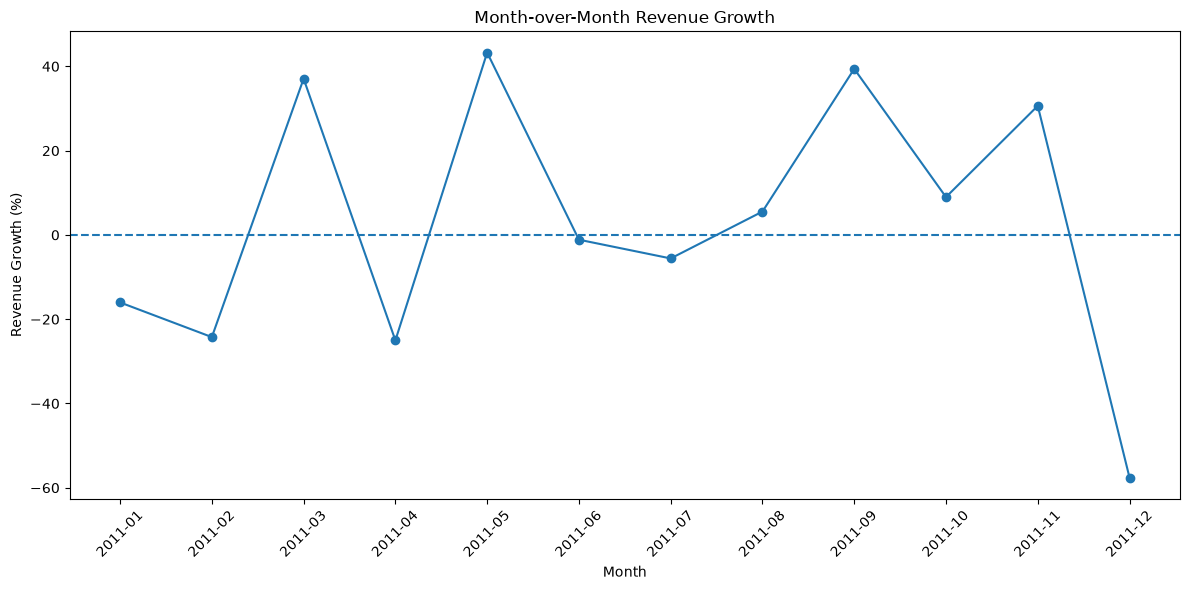

In [62]:
monthly_growth_plot = monthly_growth.copy()

monthly_growth_plot.index = monthly_growth_plot.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_plot.index,
    monthly_growth_plot.values,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

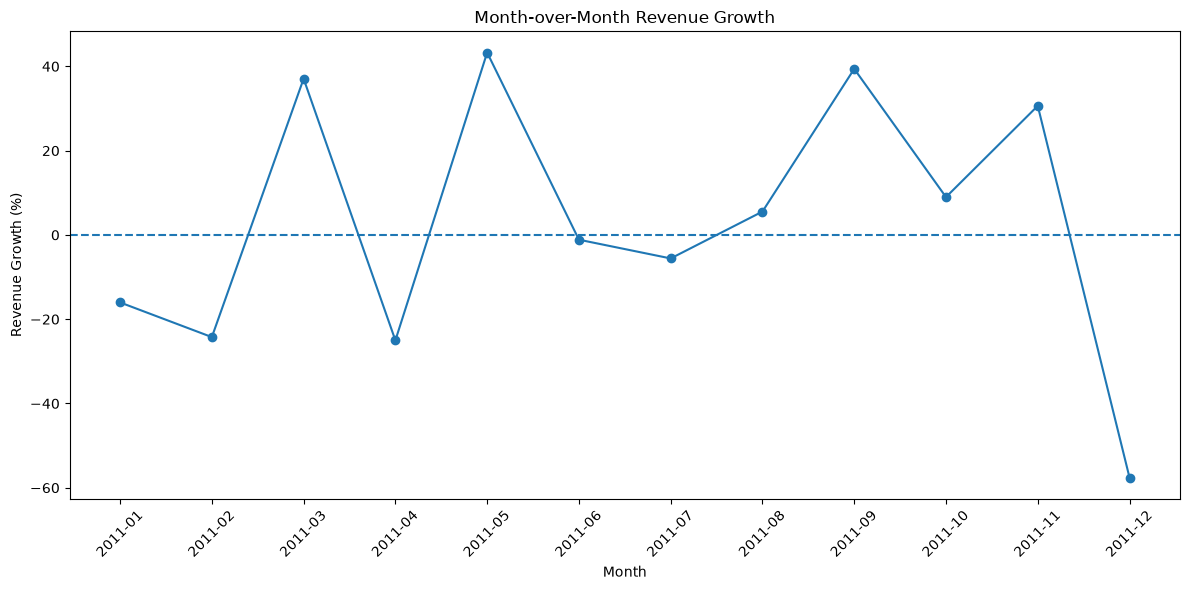

In [63]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_plot.index,
    monthly_growth_plot.values,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_revenue_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
growth_summary = pd.DataFrame({
    "Metric": [
        "Highest Monthly Growth",
        "Largest Monthly Decline"
    ],
    "Month": [
        str(highest_growth_month),
        str(largest_decline_month)
    ],
    "Percentage": [
        round(highest_growth, 2),
        round(largest_decline, 2)
    ]
})

growth_summary

,Metric,Month,Percentage
0,Highest Monthly Growth,2011-05,43.27
1,Largest Monthly Decline,2011-12,-57.59


### Monthly Growth Insights

- May 2011 recorded the highest month-over-month revenue growth at approximately **43.27%**.
- December 2011 recorded the largest apparent decline at approximately **-57.59%**.
- The December decline should not be interpreted as a genuine collapse in business performance because the dataset ends on **9 December 2011**.
- Month-over-month growth analysis highlights periods that could be investigated further for seasonal effects, marketing campaigns, product changes, or operational events.

## 10. Dataset Time Coverage

The transaction dates are analysed to determine the period covered by the dataset.

Understanding the time range is important when interpreting monthly trends, particularly because the final month contains only partial data.

In [65]:
first_transaction = sales_df["InvoiceDate"].min()
last_transaction = sales_df["InvoiceDate"].max()

print("First transaction:", first_transaction)
print("Last transaction:", last_transaction)

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [66]:
december_data = sales_df[
    sales_df["InvoiceDate"].dt.to_period("M") == "2011-12"
]

print("December transactions:", len(december_data))
print(
    "December orders:",
    december_data["InvoiceNo"].nunique()
)
print(
    "December revenue: £",
    round(december_data["Revenue"].sum(), 2)
)

December transactions: 24857
December orders: 839
December revenue: £ 637790.33


In [67]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "First Transaction",
        "Last Transaction",
        "Total Transactions",
        "Total Orders",
        "Unique Customers",
        "Unique Products",
        "Countries"
    ],
    "Value": [
        str(first_transaction),
        str(last_transaction),
        len(sales_df),
        total_orders,
        unique_customers,
        unique_products,
        unique_countries
    ]
})

dataset_summary

,Metric,Value
0,First Transaction,2010-12-01 08:26:00
1,Last Transaction,2011-12-09 12:50:00
2,Total Transactions,526052
3,Total Orders,20726
4,Unique Customers,4339
5,Unique Products,3941
6,Countries,38


### Dataset Coverage Insights

- The dataset covers transactions from **1 December 2010 to 9 December 2011**.
- The analysis therefore covers approximately one year of e-commerce activity.
- December 2011 is an incomplete month and should be treated cautiously when comparing monthly performance.
- The dataset contains more than **541,000 transactions**, providing a substantial volume of data for analysis.

In [68]:
print("Missing values in analysis dataset:")
print(sales_df.isnull().sum())

Missing values in analysis dataset:
InvoiceNo           0
StockCode           0
Description       592
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133320
Country             0
Revenue             0
Month               0
dtype: int64


In [69]:
print("Duplicate rows:", sales_df.duplicated().sum())

Duplicate rows: 0


### Data Quality Considerations

Several data-quality issues were identified during the analysis:

- **5,268 duplicate rows** were identified in the original dataset.
- **Customer IDs are missing for some transactions**, limiting customer-level analysis to identifiable customers.
- **Negative quantities** represent returns or cancellations and were analysed separately.
- Some transactions contain unusual descriptions such as postage, adjustments, or operational entries.
- The final month, December 2011, is incomplete because the dataset ends on 9 December 2011.

These factors were considered when interpreting the results to avoid misleading conclusions.

# Executive Summary

## E-Commerce Sales Analysis

This project analyses approximately **541,000 e-commerce transactions** from December 2010 to December 2011 to understand sales performance, customer behaviour, product performance and geographic revenue distribution.

### Key Findings

- **Total Revenue:** £10.64 million
- **Total Orders:** 20,726
- **Total Units Sold:** 5.65 million
- **Unique Customers:** 4,339
- **Unique Products:** 4,077
- **Countries:** 38
- **Average Order Value:** £513.47

### Business Highlights

- **November 2011** generated the highest monthly revenue at approximately **£1.50 million**.
- **November 2011** also recorded the highest order volume, with **2,884 orders**.
- The **United Kingdom** generated approximately **£9.00 million**, representing **84.59% of total revenue**.
- Customer revenue is concentrated among a relatively small number of high-value customers.
- **10,624 return/cancellation transactions** were identified, representing **484,531 returned or cancelled units**.
- May 2011 recorded the highest month-over-month revenue growth at approximately **43.27%**.

### Important Data Considerations

December 2011 is an incomplete month because the dataset ends on **9 December 2011**. Therefore, December should be interpreted cautiously when comparing monthly performance.

Negative quantities were treated as returns or cancellations and analysed separately from normal sales transactions.

In [70]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Units Sold",
        "Unique Customers",
        "Unique Products",
        "Countries",
        "Average Order Value"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_units:,}",
        f"{unique_customers:,}",
        f"{unique_products:,}",
        f"{unique_countries:,}",
        f"£{average_order_value:,.2f}"
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,"£10,642,110.80"
1,Total Orders,"20,726"
2,Total Units Sold,"5,645,017"
3,Unique Customers,"4,339"
4,Unique Products,"3,941"
5,Countries,38
6,Average Order Value,£513.47


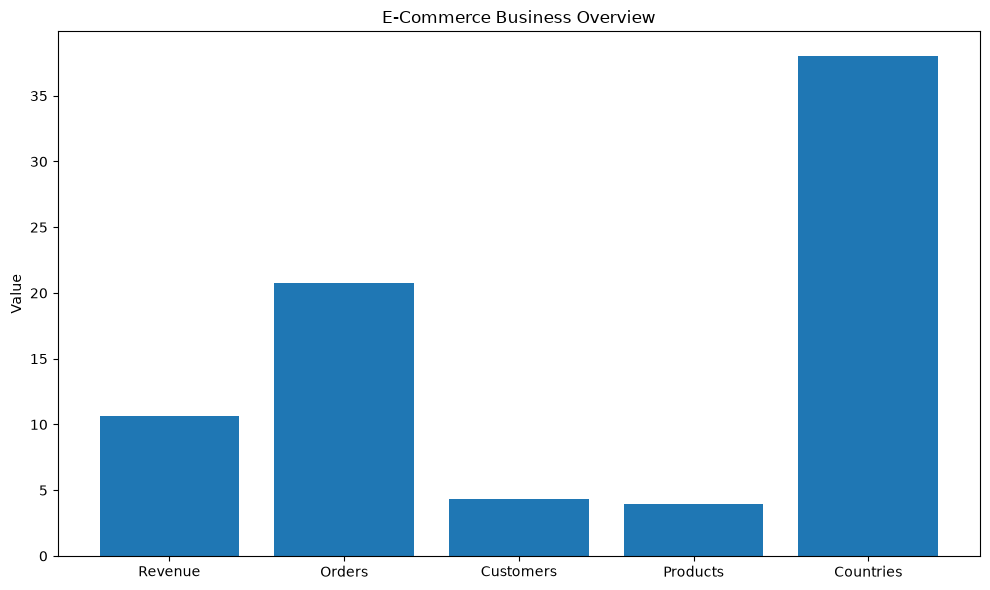

In [71]:
plt.figure(figsize=(10, 6))

plt.bar(
    ["Revenue", "Orders", "Customers", "Products", "Countries"],
    [
        total_revenue / 1_000_000,
        total_orders / 1_000,
        unique_customers / 1_000,
        unique_products / 1_000,
        unique_countries
    ]
)

plt.title("E-Commerce Business Overview")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## Business Recommendations

Based on the analysis, the following areas could be investigated further:

### 1. Reduce dependence on the UK market

Approximately **84.59% of revenue comes from the United Kingdom**. The business could investigate opportunities to expand sales in other high-potential international markets.

### 2. Focus on high-value customers

A relatively small group of customers generates substantial revenue. Customer retention strategies, loyalty programmes and personalised offers could help retain these high-value customers.

### 3. Investigate high-return products

Several products have unusually high return volumes. These products should be investigated further to understand whether returns are related to product quality, customer expectations, fulfilment issues or other operational factors.

### 4. Investigate seasonal sales patterns

November generated the highest monthly revenue and order volume. Further analysis could investigate whether this pattern is related to seasonal demand, promotions, holidays or marketing campaigns.

### 5. Improve international market performance

The Netherlands and EIRE are among the strongest international markets. Similar customer and product analysis could be performed to identify characteristics that could be replicated in other countries.

### 6. Monitor Average Order Value

Monthly AOV varies considerably. Understanding which products, customers and countries contribute to higher-value orders could help the business develop strategies to increase basket size.

## Skills Demonstrated

This project demonstrates the following Data Science skills:

- Python programming
- Pandas data manipulation
- Data cleaning
- Handling missing values
- Duplicate detection
- Feature engineering
- Groupby and aggregation
- KPI calculation
- Time-series analysis
- Customer analysis
- Product analysis
- Geographic analysis
- Return/cancellation analysis
- Data visualization with Matplotlib
- Business insight generation
- Communicating analytical findings